# Plot ERA5 Averaged Field With Basemap

This notebook reads an averaged ERA5 `.npy` field, gets latitude and longitude from a reference ERA5 NetCDF file, and plots the result on a Basemap map. It can also overlay line contours from another `.npy` field or from the difference between two `.npy` fields.

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap, to_rgba
from mpl_toolkits.basemap import Basemap, maskoceans

In [28]:
def _first_existing_name(dataset, names):
    for name in names:
        if name in dataset.coords or name in dataset.variables:
            return name
    raise KeyError(f'Could not find any of these coordinates: {names}')


def read_era5_grid(reference_file):
    """Read latitude and longitude arrays from a reference ERA5 NetCDF file."""
    with xr.open_dataset(reference_file) as ds:
        lat_name = _first_existing_name(ds, ('latitude', 'lat', 'XLAT', 'XLAT_M'))
        lon_name = _first_existing_name(ds, ('longitude', 'lon', 'XLONG', 'XLONG_M'))
        lat = np.asarray(ds[lat_name].squeeze().values)
        lon = np.asarray(ds[lon_name].squeeze().values)
    return lat, lon


def load_average_field(npy_file):
    """Load a 2-D averaged ERA5 field from a NumPy output file."""
    field = np.squeeze(np.load(npy_file))
    if field.ndim != 2:
        raise ValueError(f'Expected a 2-D field after squeeze, got shape {field.shape}')
    return field


def _prepare_rectilinear_grid(field, lat, lon):
    if lat.ndim != 1 or lon.ndim != 1:
        if field.shape != lat.shape or field.shape != lon.shape:
            raise ValueError('For 2-D lat/lon grids, lat, lon, and field must have the same shape.')
        return lon, lat, field

    if field.shape == (lon.size, lat.size):
        field = field.T
    elif field.shape != (lat.size, lon.size):
        raise ValueError(f'Field shape {field.shape} does not match lat/lon sizes {(lat.size, lon.size)}')

    if np.nanmax(lon) > 180.0:
        lon = ((lon + 180.0) % 360.0) - 180.0
        order = np.argsort(lon)
        lon = lon[order]
        field = field[:, order]

    if lat[0] > lat[-1]:
        lat = lat[::-1]
        field = field[::-1, :]

    lon2d, lat2d = np.meshgrid(lon, lat)
    return lon2d, lat2d, field


def _parse_domain(domain, lon2d, lat2d):
    if domain is None:
        return (
            float(np.nanmin(lon2d)),
            float(np.nanmax(lon2d)),
            float(np.nanmin(lat2d)),
            float(np.nanmax(lat2d)),
        )

    if isinstance(domain, dict):
        lon_min = domain['lon_min']
        lon_max = domain['lon_max']
        lat_min = domain['lat_min']
        lat_max = domain['lat_max']
    else:
        lon_min, lon_max, lat_min, lat_max = domain

    lon_min, lon_max = float(lon_min), float(lon_max)
    lat_min, lat_max = sorted((float(lat_min), float(lat_max)))
    if lon_min >= lon_max:
        raise ValueError('Use lon_min < lon_max. Dateline-crossing domains are not handled in this notebook.')
    return lon_min, lon_max, lat_min, lat_max


def _subset_domain(lon2d, lat2d, field, domain):
    lon_min, lon_max, lat_min, lat_max = _parse_domain(domain, lon2d, lat2d)
    mask = (lon2d >= lon_min) & (lon2d <= lon_max) & (lat2d >= lat_min) & (lat2d <= lat_max)
    if not np.any(mask):
        raise ValueError('The requested domain does not overlap the ERA5 grid.')

    rows = np.where(np.any(mask, axis=1))[0]
    cols = np.where(np.any(mask, axis=0))[0]
    row_slice = slice(rows.min(), rows.max() + 1)
    col_slice = slice(cols.min(), cols.max() + 1)
    return lon2d[row_slice, col_slice], lat2d[row_slice, col_slice], field[row_slice, col_slice], (lon_min, lon_max, lat_min, lat_max)


def _valid_values(field, error_message='No valid data values remain after masking/subsetting.'):
    values = np.ma.asarray(field)
    if np.ma.isMaskedArray(values):
        values = values.compressed()
    else:
        values = np.asarray(values).ravel()
    values = values[np.isfinite(values)]
    if values.size == 0:
        raise ValueError(error_message)
    return values


def _mask_land_points(lon2d, lat2d, field, resolution='c', grid=5):
    """Mask land points in a gridded field using Basemap's land/sea mask."""
    values = np.ma.asarray(field)
    data = np.ma.filled(values, np.nan)
    data_mask = np.ma.getmaskarray(values) | ~np.isfinite(data)
    ocean_masked = maskoceans(lon2d, lat2d, np.ones_like(data, dtype=float), inlands=True, resolution=resolution, grid=grid)
    ocean_or_lake_mask = np.ma.getmaskarray(ocean_masked)
    land_mask = ~ocean_or_lake_mask
    return np.ma.array(data, mask=data_mask | land_mask)


def _build_levels(field, shading_levels=None, level_count=21):
    if shading_levels is None:
        values = _valid_values(field)
        vmin = float(np.nanmin(values))
        vmax = float(np.nanmax(values))
        if np.isclose(vmin, vmax):
            vmin -= 0.5
            vmax += 0.5
        shading_levels = np.linspace(vmin, vmax, int(level_count))
    else:
        shading_levels = np.asarray(shading_levels, dtype=float)

    if shading_levels.ndim != 1 or shading_levels.size < 2:
        raise ValueError('shading_levels must contain at least two values.')
    if not np.all(np.diff(shading_levels) > 0):
        raise ValueError('shading_levels must be strictly increasing.')
    return shading_levels


def _insert_center_white_bounds(levels, a):
    a = abs(float(a))
    if not np.isfinite(a) or a <= 0.0:
        raise ValueError('a must be a positive finite number for the white shading range [-a, a].')
    levels = np.asarray(levels, dtype=float)
    keep = ~np.isclose(levels, -a) & ~np.isclose(levels, a)
    return np.sort(np.concatenate([levels[keep], [-a, a]]))


def _blend_rgba(color0, color1, fraction):
    fraction = np.clip(float(fraction), 0.0, 1.0)
    color0 = np.asarray(to_rgba(color0), dtype=float)
    color1 = np.asarray(to_rgba(color1), dtype=float)
    return color0 * (1.0 - fraction) + color1 * fraction


def _build_interval_cmap(levels, lower_color='royalblue', upper_color='firebrick', lowest_interval_white=False, center_white_abs_value=None):
    interval_count = max(len(levels) - 1, 1)
    if center_white_abs_value is None:
        base = LinearSegmentedColormap.from_list('era5_shading', [lower_color, upper_color])
        colors = base(np.linspace(0.0, 1.0, interval_count))
    else:
        a = abs(float(center_white_abs_value))
        lower_edges = np.asarray(levels[:-1], dtype=float)
        upper_edges = np.asarray(levels[1:], dtype=float)
        midpoints = 0.5 * (lower_edges + upper_edges)
        data_min = float(np.nanmin(levels))
        data_max = float(np.nanmax(levels))
        negative_span = max(-a - data_min, np.finfo(float).eps)
        positive_span = max(data_max - a, np.finfo(float).eps)
        colors = []
        for lower_edge, upper_edge, midpoint in zip(lower_edges, upper_edges, midpoints):
            if lower_edge >= -a and upper_edge <= a:
                colors.append(to_rgba('white'))
            elif midpoint < -a:
                fraction = (midpoint - data_min) / negative_span
                colors.append(_blend_rgba(lower_color, 'white', fraction))
            else:
                fraction = (midpoint - a) / positive_span
                colors.append(_blend_rgba('white', upper_color, fraction))
        colors = np.asarray(colors)
    if lowest_interval_white:
        colors[0] = (1.0, 1.0, 1.0, 1.0)
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(levels, cmap.N)
    return cmap, norm


def plot_era5_average_field(
    npy_file,
    reference_file,
    *,
    domain=None,
    shading_levels=None,
    level_count=21,
    lower_color='royalblue',
    upper_color='firebrick',
    lowest_interval_white=False,
    center_white_abs_value=None,
    mask_land=False,
    land_color='lightgray',
    land_mask_resolution=None,
    land_mask_grid=5,
    add_contours=False,
    contour_npy_file=None,
    contour_difference_npy_file=None,
    contour_reference_file=None,
    contour_levels=None,
    contour_count=7,
    contour_symmetric=False,
    contour_colors='black',
    contour_linewidths=0.8,
    contour_linestyles=None,
    contour_labels=True,
    contour_label_fontsize=8,
    xlabel='Longitude',
    ylabel='Latitude',
    xlabel_fontsize=12,
    ylabel_fontsize=12,
    xtick_fontsize=10,
    ytick_fontsize=10,
    x_tick_count=7,
    y_tick_count=7,
    title=None,
    title_fontsize=13,
    cbar_label=None,
    cbar_label_fontsize=11,
    cbar_tick_fontsize=9,
    figsize=(12, 6),
    map_resolution='c',
    coastline_linewidth=0.6,
    country_linewidth=0.4,
    extend='both',
):
    """Plot an averaged ERA5 npy field on a latitude-longitude Basemap map.

    Parameters
    ----------
    domain : tuple, dict, or None
        Use (lon_min, lon_max, lat_min, lat_max), for example (-180, 180, -90, 90).
        A dict with lon_min/lon_max/lat_min/lat_max is also accepted.
    shading_levels : sequence or None
        Specific color interval boundaries for the shaded field. If None, level_count
        evenly spaced intervals are created from the plotted data range.
    lowest_interval_white : bool
        If True, the first shaded interval is colored white.
    center_white_abs_value : float or None
        If provided, negative intervals fade from lower_color to white, intervals inside
        [-center_white_abs_value, center_white_abs_value] are white, and positive intervals
        fade from white to upper_color. The two bounds are inserted into shading_levels automatically.
    mask_land : bool
        If True, mask shaded and contour data over land and draw land as land_color.
    land_color : str
        Color used for masked land points.
    land_mask_resolution : str or None
        Basemap land/sea mask resolution. If None, map_resolution is used.
    land_mask_grid : float
        Basemap land/sea mask grid spacing in minutes. Smaller values give a sharper mask.
    add_contours : bool
        If True, contour lines are overlaid.
    contour_npy_file : str or Path or None
        Field to contour. If omitted, contours use the shaded field.
    contour_difference_npy_file : str or Path or None
        If provided, contours use contour_npy_file - contour_difference_npy_file.
        If contour_npy_file is omitted, contours use npy_file - contour_difference_npy_file.
    contour_symmetric : bool
        If True and contour_levels is None, use levels symmetric around zero.
    """
    field_raw = load_average_field(npy_file)
    lat, lon = read_era5_grid(reference_file)
    lon2d, lat2d, field = _prepare_rectilinear_grid(field_raw, lat, lon)
    lon_plot, lat_plot, field_plot, map_domain = _subset_domain(lon2d, lat2d, field, domain)
    lon_min, lon_max, lat_min, lat_max = map_domain
    land_mask_resolution = land_mask_resolution or map_resolution
    #if mask_land:
    #    field_plot = _mask_land_points(lon_plot, lat_plot, field_plot, resolution=land_mask_resolution, grid=land_mask_grid)

    levels = _build_levels(field_plot, shading_levels=shading_levels, level_count=level_count)
    if center_white_abs_value is not None:
        levels = _insert_center_white_bounds(levels, center_white_abs_value)
    cmap, norm = _build_interval_cmap(levels, lower_color=lower_color, upper_color=upper_color, lowest_interval_white=lowest_interval_white, center_white_abs_value=center_white_abs_value)

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    basemap = Basemap(
        projection='cyl',
        llcrnrlon=lon_min,
        urcrnrlon=lon_max,
        llcrnrlat=lat_min,
        urcrnrlat=lat_max,
        resolution=map_resolution,
        ax=ax,
    )

    x, y = basemap(lon_plot, lat_plot)
    shade = basemap.contourf(x, y, field_plot, levels=levels, cmap=cmap, norm=norm, extend=extend)
    basemap.drawcoastlines(linewidth=coastline_linewidth)
    basemap.drawcountries(linewidth=country_linewidth)
    basemap.drawmapboundary(linewidth=0.6)

    contour_set = None
    if add_contours:
        contour_reference_file = contour_reference_file or reference_file
        if contour_npy_file is None:
            contour_raw = field_raw.copy()
        else:
            contour_raw = load_average_field(contour_npy_file)
        if contour_difference_npy_file is not None:
            contour_raw = contour_raw - load_average_field(contour_difference_npy_file)

        contour_lat, contour_lon = read_era5_grid(contour_reference_file)
        contour_lon2d, contour_lat2d, contour_field = _prepare_rectilinear_grid(contour_raw, contour_lat, contour_lon)
        contour_lon_plot, contour_lat_plot, contour_plot, _ = _subset_domain(contour_lon2d, contour_lat2d, contour_field, domain)
        if mask_land:
            contour_plot = _mask_land_points(contour_lon_plot, contour_lat_plot, contour_plot, resolution=land_mask_resolution, grid=land_mask_grid)
        contour_x, contour_y = basemap(contour_lon_plot, contour_lat_plot)
        if contour_levels is None:
            contour_values = _valid_values(contour_plot, error_message='No valid contour data remain after masking/subsetting.')
            contour_min = float(np.nanmin(contour_values))
            contour_max = float(np.nanmax(contour_values))
            if contour_symmetric:
                contour_abs = max(abs(contour_min), abs(contour_max))
                contour_min, contour_max = -contour_abs, contour_abs
            if np.isclose(contour_min, contour_max):
                contour_min -= 0.5
                contour_max += 0.5
            contour_levels = np.linspace(contour_min, contour_max, int(contour_count))
        contour_levels = np.asarray(contour_levels, dtype=float)
        contour_levels = contour_levels[~np.isclose(contour_levels, 0.0)] if contour_symmetric else contour_levels
        if contour_linestyles is None:
            contour_linestyles = ['dotted' if value < 0 else 'solid' for value in contour_levels]
        contour_set = basemap.contour(contour_x, contour_y, contour_plot, levels=contour_levels, colors=contour_colors, linewidths=contour_linewidths, linestyles=contour_linestyles)
        if contour_labels:
            ax.clabel(contour_set, inline=True, fontsize=contour_label_fontsize, fmt='%g')

    cbar = fig.colorbar(shade, ax=ax, pad=0.02, shrink=0.88)
    if cbar_label:
        cbar.set_label(cbar_label, fontsize=cbar_label_fontsize)
    cbar.ax.tick_params(labelsize=cbar_tick_fontsize)

    ax.set_xlabel(xlabel, fontsize=xlabel_fontsize)
    ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
    #ax.set_xticks(np.linspace(lon_min, lon_max, int(x_tick_count)))
    #ax.set_yticks(np.linspace(lat_min, lat_max, int(y_tick_count)))
    ax.set_yticks([0, 10, 20, 30])
    ax.set_xticks([100, 110, 120, 130, 140, 150])
    ax.tick_params(axis='x', labelsize=xtick_fontsize)
    ax.tick_params(axis='y', labelsize=ytick_fontsize)
    if mask_land:
        ax.set_facecolor(land_color)
        basemap.fillcontinents(color=land_color, lake_color=land_color, zorder=3)    
    ax.grid(True, linewidth=1, color='0', alpha=0.5)

    if title:
        ax.set_title(title, fontsize=title_fontsize)

    return fig, ax, basemap, shade, contour_set


def plot_era5_average_field_white_range(
    npy_file,
    reference_file,
    *,
    a,
    shading_levels=None,
    **kwargs,
):
    """Plot an ERA5 field with a diverging color scheme and white values in [-a, a].

    Negative values fade from lower_color to white as they approach -a. Values
    from -a to a are white. Positive values fade from white to upper_color.
    All keyword arguments accepted by plot_era5_average_field can also be passed here.
    """
    return plot_era5_average_field(
        npy_file,
        reference_file,
        shading_levels=shading_levels,
        center_white_abs_value=a,
        **kwargs,
    )


Using shaded field:     /N/u/ckieu/BigRed200/codex/diagnosePy/outputs/era5_1940_1960_09_W_950.npy
Using contour subtract: /N/u/ckieu/BigRed200/codex/diagnosePy/outputs/era5_2000_2020_09_W_950.npy
Using grid:  /N/u/ckieu/BigRed200/codex/diagnosePy/data/era5/1946_1960/ERA5_sfc_19460401T000000.000000000.nc


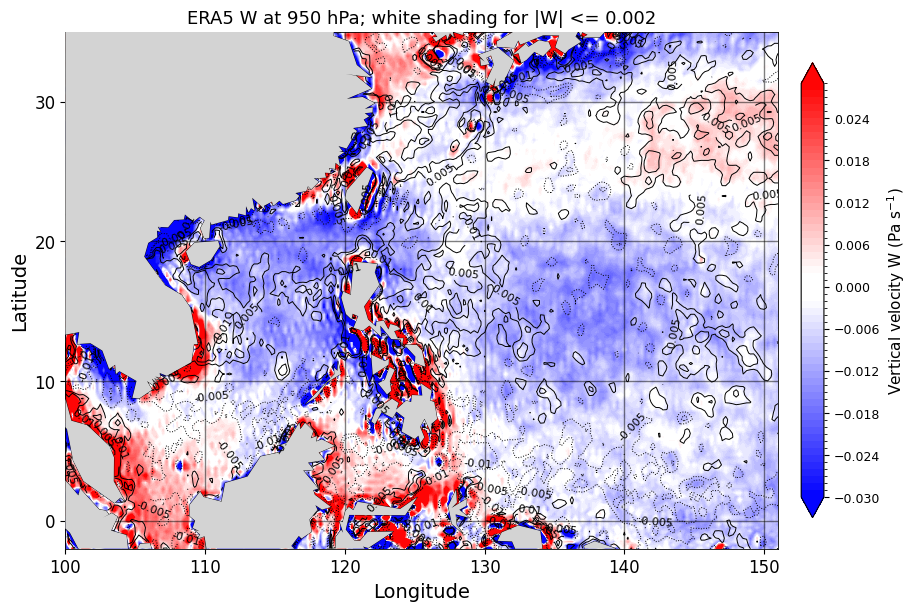

In [29]:
NPY_FILE = '/N/u/ckieu/BigRed200/codex/diagnosePy/outputs/era5_1940_1960_09_W_950.npy'
DIFFERENCE_FILE = '/N/u/ckieu/BigRed200/codex/diagnosePy/outputs/era5_2000_2020_09_W_950.npy'
REFERENCE_FILE = '/N/u/ckieu/BigRed200/codex/diagnosePy/data/era5/1946_1960/ERA5_sfc_19460401T000000.000000000.nc'
print(f'Using shaded field:     {NPY_FILE}')
print(f'Using contour subtract: {DIFFERENCE_FILE}')
print(f'Using grid:  {REFERENCE_FILE}')

white_band = 0.002
w_levels = np.arange(-0.03, 0.03, 0.001)
difference_contour_levels = np.array([-0.01, -0.005, 0.005, 0.01])

fig, ax, basemap, shade, contours = plot_era5_average_field_white_range(
    NPY_FILE,
    REFERENCE_FILE,
    a=white_band,
    domain=(100, 151, -2, 35),
    shading_levels=w_levels,
    lower_color='blue',
    upper_color='red',
    lowest_interval_white=False,
    mask_land=True,
    land_color='lightgray',
    add_contours=True,
    contour_npy_file=NPY_FILE,
    contour_difference_npy_file=DIFFERENCE_FILE,
    contour_levels=difference_contour_levels,
    contour_symmetric=True,
    contour_colors='black',
    contour_linewidths=0.7,
    xlabel_fontsize=14,
    ylabel_fontsize=14,
    xtick_fontsize=12,
    ytick_fontsize=12,
    x_tick_count=6,
    y_tick_count=6,
    title=f'ERA5 W at 950 hPa; white shading for |W| <= {white_band:g}',
    cbar_label='Vertical velocity W (Pa s$^{-1}$)',
)
#output_figure = Path(NPY_FILE).resolve().parent / 'era5_1940_1950_04_W_950_map_diff_contours.png'
#fig.savefig(output_figure, dpi=150, bbox_inches='tight')
#print(f'Saved {output_figure}')
plt.show()